#### Step 1: Import Libraries & API Keys

In [2]:
import gradio as gr
import os
import groq
import json
import requests
import tiktoken
from pprint import pprint
from openai import OpenAI
from dotenv import load_dotenv

load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

client = OpenAI()

if OPENAI_API_KEY is None:
    raise Exception("API key is missing.")

client = OpenAI()


c:\Users\Orchid X\OneDrive\Desktop\AI_Engineering\ai_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Step 2: Load the documents

In [3]:
document = """
The Best Work of Our Lives CULTURE MEMO At Netflix, we aspire to entertain the world, thrilling audiences everywhere. To do that, we’ve developed an unusual company culture focused on excellence, and creating an environment where talented people can thrive — lifting ourselves, each other and our audiences higher and higher. \
    This document is about that culture, which is based on four core principles: \
    ● The Dream Team: We aim only to have high performers at Netflix — people who are great at what they do, and even better at working together. \
    ● People over Process: You get better outcomes when employees have the information and freedom to make decisions for themselves. We hire unusually responsible people who thrive on this openness and freedom.  \
    ● Uncomfortably Exciting: To entertain the world, we need to be bold and ambitious. That means embracing the thrill of what’s next — even when it’s uncomfortable.  \
    ● Great and Always Better: We often say Netflix sucks today compared to where we can be tomorrow. We need the self-awareness to understand what should be better, and the discipline and resilience to get there.     \
    While we don’t always live up to these principles, most people who join Netflix are pleasantly surprised by how great their colleagues are and the way we empower people at every level. As our business grows and evolves, our culture (and this document) will, too. What won’t change is our focus on excellence, and our determination to ensure that Netflix remains a place where great people can do the best work of their lives. \
    If this sounds exciting, you’ll probably love it here. But Netflix is not for everyone, so please read on.  THE DREAM TEAM We believe that what makes a fantastic workplace isn’t a great office or free meals and massages — although we have some nice perks. It’s the people. Imagine working alongside stunning colleagues who are great at what they do, and even better at working together. \
    It’s why we model ourselves on a professional sports team, not a family. Families are about unconditional love. They can also be dysfunctional, as anyone who’s watched Ozark or Wednesday knows. Professional sports teams, on the other hand, focus on performance and picking the right person for every position, even when that means swapping out someone they love for a better player. \
        © 2024 Netflix, Inc. All rights reserved. | Last updated: June 2024 | English Version \
    While every member of our Dream Team has different skills, we look for common strengths that make us better together. These are the values we value: \
        ● Selflessness — you are humble when searching for the best ideas; you seek what’s best for Netflix, not yourself or your team; you take time to help others succeed.  \
        ● Judgment — you look beyond short term fixes in favor of long term solutions; you make wise decisions despite ambiguity; you use data to inform your intuition. \
        ● Candor — you willingly receive and give feedback; you are open about what’s working and what needs to improve; you admit mistakes openly and share learnings widely.  \
        ● Creativity — you welcome new ideas; you are passionate and persistent in pursuit of more innovative solutions; you value artistic expression. \
        ● Courage — you are vulnerable in search for the truth; you are willing to risk failure, or challenge the status quo, in the pursuit of excellence.  \
        ●  Inclusion — you recognize your biases and work to counteract them; you try to ensure everyone at Netflix can do their best work, whatever their culture, identity or background.  \
        ● Curiosity — you learn rapidly and eagerly; you are more interested in other people’s ideas than your own; you’re humble about what you don’t yet know. \
        ● Resilience — you quickly adapt to changing circumstances; you make tough decisions without agonizing or long delay; you embrace a hard challenge. \
            
        It’s easy to talk about values and harder to live by them. We all work hard to keep each other accountable for upholding these standards, especially our leaders, because excellence and honesty go hand in hand. \
        It’s why we invest in strong professional relationships that build trust and help people assume good intent. This, in turn, enables us to practice extraordinary candor — ensuring constructive feedback is part of our everyday work (like brushing your teeth). \
        It takes courage and vulnerability to ask someone how you could do better, or to seek alternative opinions about the best way forward, and integrity only to say things about a colleague that you’re willing to share with them directly. \
        This is especially true when you’re giving feedback to someone more senior or from a different background, or if you come from a culture or company where deference is the norm. But extraordinary candor helps us improve faster as individuals and a company.  \
        Since a high performer in any role is many times more effective than the average employee, our Dream Team is driven by performance — not seniority, tenure or unconditional loyalty. It’s also why we focus on maintaining a high performance culture. \
        To recruit and retain stunning colleagues, we pay personal top of market for the role and location — a judgment about what that person could make in a similar role at another company, and what we would pay to keep or replace them. \
        We expect leaders to be strong developers of talent. And to ensure they have the right player at every position, we ask them to apply what we call the “keeper test”1 — asking “if X wanted to leave, would I fight to keep them?” Or “knowing everything I know today, would I hire X again?” If the answer is no, we believe it’s fairer to everyone to part ways quickly.  \
        1The “keeper test” name came from our co-founder, Reed Hastings, who remembers catching a fish as a child and his dad saying, “That’s a keeper, Reed!” © 2024 Netflix, Inc. All rights reserved. | Last updated: June 2024 | English Version \
            
        In the abstract, the keeper test can sound scary. In reality, we encourage everyone to speak to their managers about what’s going well and what’s not on a regular basis. This helps avoid surprises. Managers also evaluate team members on their whole record, rather than focusing on the mistakes or bets that didn’t pay off. \
        On the Dream Team, you need people who challenge the status quo and try new things. So we stick with employees through short-term bumps.   No matter how brilliant someone may be, there’s no place in our Dream Team for people who don’t treat their colleagues with decency and respect. \
        When you have talented people who work well together — trusting each other’s intentions and respecting their differences — it makes everyone more successful.  \
        PEOPLE OVER PROCESS Many of us have worked at companies where decisions were made top down, there was little transparency and it felt hard to make a difference — or even get basic things done. \
        At Netflix, we aim to inspire and empower more than just manage because people can have a greater impact when they’re free to make decisions about their own work.  As part of this, we strive to develop good decision-making muscles at every level of the company, priding ourselves on how few, not how many, decisions senior leaders make. \
        We expect managers to practice context not control — giving their teams the context and clarity needed to make good decisions instead of trying to control everything themselves. We also help employees learn by sharing a lot of information internally, including through memos where they can comment and ask questions. \
        It takes an unusually responsible person to thrive on this level of freedom — someone who’s self-motivated, self-aware and self-disciplined, who doesn’t wait to be told what to do and picks up the trash like they would at home. \
        That said, context not control should not be confused with hands-off management. Managers need to be involved in the work being done around them, and actively coach their teams. They may also have to step in when someone is about to make a decision that is unethical or could materially harm Netflix, during a crisis or if a new team member lacks the full context.  \
        We avoid decision-making by committee, which tends to slow companies down and undermine accountability. For every significant decision, we identify an informed captain who’s responsible for making a judgment call on the right way ahead. \
        Then different teams, each led by their own informed captain, implement the decision. This highly aligned and loosely coupled approach gives teams the freedom to move quickly and operate independently, while ensuring responsibility for the outcome.  \
        We’ve learned that the best ideas can come from anywhere, which is why we expect informed captains to seek out different opinions and listen to people at every level. We call this farming for dissent. Of course, not all opinions are created equal — and with 10,000-plus employees, it’s impractical for everyone to weigh in on most decisions (this memo being an exception). \
        So on an important creative decision, for example, the opinion of someone working in TV, film or games will carry more weight than an engineer, and vice versa when it comes to our product or technology. After a decision is made, we expect everyone, including the people who argued © 2024 Netflix, Inc. All rights reserved. | Last updated: June 2024 | English Version for a different approach, to disagree and commit. \
        This helps ensure the outcome is as successful as possible. Afterwards, when the impact is clear, the informed captain should reflect on their choices — what worked and what didn’t — so everyone can learn how to do better next time.  Launching a game, TV show or film, running a marketing campaign, managing compensation and closing a quarter all take process. \
        And companies need strict rules against things like harassment, marginalizing colleagues, leaking company information, or insider trading. But we work hard to keep rules at Netflix to a minimum and ensure any process is good (simple, efficient, impactful). Our vacation policy, for example, is two words: “Take vacation.” And our expenses policy is just five words: “Act in Netflix’s best interests.” \
        This (almost) no rules rule gives employees the freedom to exercise their judgment. It also prevents the process creep that typically happens when companies grow and try to dummy proof their organizations — stifling creativity and making it harder for businesses to adapt.  You might think that this kind of freedom would lead to chaos. \
        In reality, while we’ve had our fair share of failures — and a few people have taken advantage of our culture in bad ways — our emphasis on individual autonomy has created an extremely successful business, with many opportunities for employees to develop and grow. In entertainment and technology, our biggest threat is a lack of creativity, adaptability and innovation. \
        It’s why trying to minimize rules and processes (rather than errors) — while giving people the freedom to use their own judgment and learn from their mistakes — is a far superior recipe for long-term success.  UNCOMFORTABLY EXCITING Netflix is programming for well over half a billion2 people globally — something no other entertainment company has ever done before. \
        Success requires us to be bold and ambitious, to think differently, experiment and adapt (often quickly). This is true whether we’re designing a new product feature, working to improve our recommendations, developing a marketing campaign or creating a TV show or game. \
        Many people will be happier at companies that are more stable or take fewer risks. Netflix works best if you value experimentation, enjoy the uncomfortable excitement of a new or challenging project and have the resilience to thrive in this environment. ARTISTIC EXPRESSION Representation matters. \
        Our members come from many different backgrounds and cultures, and they want to see a wide variety of stories and people on screen. This diversity is wonderful and it can create real tension since we all have such different views about what’s acceptable — and what’s harmful — on TV. \
        While every show, film or game is different, we approach them with the same set of principles: we support the artistic expression of the creators we choose to work with; we program for a wide variety of audiences, cultures and tastes; and we provide ratings, content advisories and parental controls in multiple languages to help members choose what to watch or play. \
        As employees, we support these principles, even if some stories run counter to our personal values. And we understand that, depending 2As of Q1 2024 ~260 million households subscribe to Netflix. Assuming ~2 people per household — which is conservative — that means our audience is over 500M.   \
            © 2024 Netflix, Inc. All rights reserved. | Last updated: June 2024 | English Version on our roles, we may need to work on TV shows, films or games we perceive to be harmful. If you’d find it hard to support the breadth of our slate, Netflix is probably not the best place for you.  \
            GREAT AND ALWAYS BETTER Netflix has come a long way since we mailed our first DVD in 1998. But we're nowhere close to where we want to be in the future. It’s why we care so much about the Dream Team, putting people over process and creating an environment where everyone feels a sense of responsibility to make us better. \
            We believe this approach is the surest path to excellence and long term success.  It’s also why we constantly seek to improve our culture, not preserve it. Every new employee helps shape how we work — finding new ways to accomplish more together. \
            This creates a better experience for our members, employees, creators and partners, which in turn propels our long term growth and success. It’s how we entertain the world and build a wildly successful business. \
            As he has since our first culture deck was written in 2009, Antoine de Saint-Exupéry, the author of The Little Prince, shows us the way: If you want to build a ship, don't drum up the people to gather wood, divide the work, and give orders. Instead, teach them to yearn for the vast and endless sea. 
"""

#### Step 3: Chunk the document

In [5]:
import re


def chunk_text(text: str, chunk_size: int = 500, overlap: int = 50) -> list[str]:
    """
    Split `text` into overlapping chunks of at most `chunk_size` characters,
    where each new chunk overlaps the previous one by `overlap` characters.

    When a chunk would end mid-sentence/paragraph, the cut point is pulled
    back to the nearest natural boundary, checked in this priority order:
        1. paragraph break ("\\n\\n")
        2. newline ("\\n")
        3. sentence end (".", "!", "?" followed by whitespace or end of text)
        4. space (" ")

    The boundary is only used if it falls past the halfway point of the
    chunk -- otherwise the chunk would end up too short, so the original
    hard cut at `chunk_size` is kept instead.

    Args:
        text: The input text to split.
        chunk_size: Maximum number of characters per chunk.
        overlap: Number of characters each chunk overlaps with the previous one.

    Returns:
        A list of text chunks.
    """
    n = len(text)
    chunks = []
    start = 0

    while start < n:
        end = min(start + chunk_size, n)

        # Only look for a nicer boundary if this isn't the final chunk.
        if end < n:
            halfway = start + chunk_size // 2
            search_region = text[halfway:end]
            boundary = None

            # 1. paragraph break
            idx = search_region.rfind("\n\n")
            if idx != -1:
                boundary = halfway + idx + 2

            # 2. newline
            if boundary is None:
                idx = search_region.rfind("\n")
                if idx != -1:
                    boundary = halfway + idx + 1

            # 3. sentence end (. ! ? followed by whitespace or end of string)
            if boundary is None:
                matches = list(re.finditer(r"[.!?](\s|$)", search_region))
                if matches:
                    boundary = halfway + matches[-1].end()

            # 4. space
            if boundary is None:
                idx = search_region.rfind(" ")
                if idx != -1:
                    boundary = halfway + idx + 1

            if boundary is not None:
                end = boundary

        chunks.append(text[start:end])

        if end >= n:
            break

        # Move start forward, keeping the requested overlap, but always
        # guarantee forward progress to avoid an infinite loop on edge cases.
        start = max(end - overlap, start + 1)

    return chunks

# encoding = tiktoken.encoding_for_model("gpt-4.1-mini")
# total_tokens = 0

# for i, chunk in enumerate(chunks):
#     token_count = len(encoding.encode(chunk))
#     total_tokens += token_count
#     print(f"Chunk {i+1}: " f"{len(chunk)} chars | " f"{token_count} tokens")
# print(f"\nTotal tokens across all chunks: {total_tokens}")



In [6]:
chunks = chunk_text(document, 550, 50)

for i, chunk in enumerate(chunks):
    print(f"--- Chunk {i} | {len(chunk)} characters ---")
    print(chunk)
    print()


--- Chunk 0 | 327 characters ---

The Best Work of Our Lives CULTURE MEMO At Netflix, we aspire to entertain the world, thrilling audiences everywhere. To do that, we’ve developed an unusual company culture focused on excellence, and creating an environment where talented people can thrive — lifting ourselves, each other and our audiences higher and higher. 

--- Chunk 1 | 488 characters ---
, each other and our audiences higher and higher.     This document is about that culture, which is based on four core principles:     ● The Dream Team: We aim only to have high performers at Netflix — people who are great at what they do, and even better at working together.     ● People over Process: You get better outcomes when employees have the information and freedom to make decisions for themselves. We hire unusually responsible people who thrive on this openness and freedom. 

--- Chunk 2 | 433 characters ---
e people who thrive on this openness and freedom.      ● Uncomfortably Exciting: T

#### Generate embeddings for all chunks

In [7]:
response = client.embeddings.create(
    model = "text-embedding-3-small",
    input = chunks
)

embeddings = [item.embedding for item in response.data]



In [8]:
pprint(response.data)

# verify enbeddings
print(f"Generated {len(embeddings)} embeddings")
print(f"Each embedding has {len(embeddings[0])} dimensions")

[Embedding(embedding=[0.037017822265625, 0.0122222900390625, -0.030609130859375, 0.040924072265625, 0.0172882080078125, -0.0513916015625, -0.00905609130859375, 0.049530029296875, -0.01007843017578125, -0.00972747802734375, 0.004634857177734375, -0.0159912109375, -0.042633056640625, -0.05096435546875, 0.0242919921875, 0.035675048828125, -0.038177490234375, -0.048919677734375, -0.006183624267578125, -0.042083740234375, 0.017120361328125, 0.032562255859375, -0.00916290283203125, 0.036529541015625, 0.0018987655639648438, 0.00325775146484375, -0.09136962890625, 0.07147216796875, -0.0187530517578125, -0.01181793212890625, -0.035247802734375, -0.0203704833984375, 0.017608642578125, 0.00421905517578125, 0.0225830078125, 0.014892578125, 0.033782958984375, -0.004673004150390625, 0.057525634765625, -0.006542205810546875, -0.0209503173828125, -0.01378631591796875, 0.044830322265625, 0.0162811279296875, 0.01454925537109375, -0.040008544921875, -0.0035533905029296875, 0.0121612548828125, 0.019195556

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE


def plot_embeddings_2d(embeddings, perplexity=30):
    X = np.array(embeddings)
    perplexity = min(perplexity, len(X) - 1)
    coords = TSNE(n_components=2, perplexity=perplexity,
                  random_state=42).fit_transform(X)

    plt.figure(figsize=(8, 6))
    plt.scatter(coords[:, 0], coords[:, 1], s=60, alpha=0.8)
    for i, (x, y) in enumerate(coords):
        plt.annotate(str(i), (x, y), fontsize=8, alpha=0.7)

    plt.title("Embeddings in 2D (t-SNE)")
    plt.tight_layout()
    plt.show()
    return coords




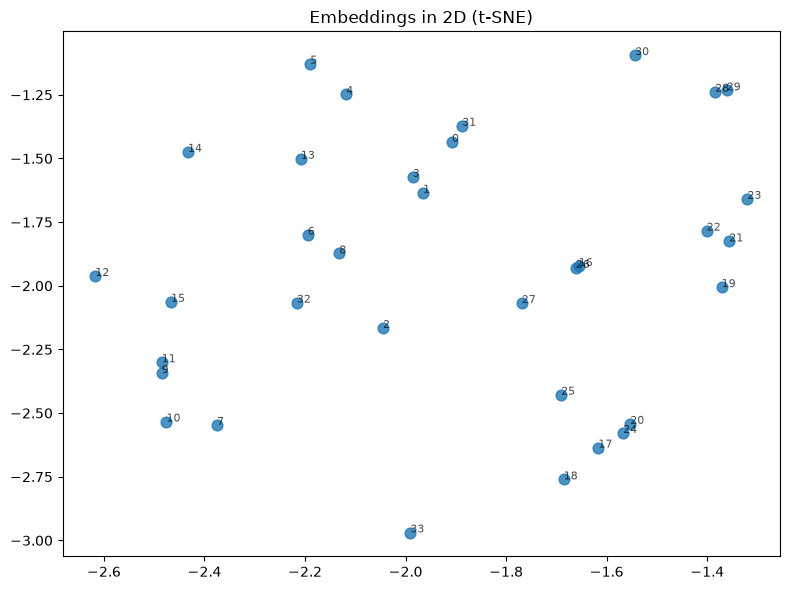

array([[-1.907602 , -1.4345672],
       [-1.9651021, -1.6348306],
       [-2.0448241, -2.165518 ],
       [-1.9858257, -1.5725245],
       [-2.1179929, -1.2469796],
       [-2.1894226, -1.1275241],
       [-2.1945584, -1.7998384],
       [-2.3750718, -2.5468037],
       [-2.1316469, -1.8732313],
       [-2.4851096, -2.343296 ],
       [-2.475535 , -2.5332735],
       [-2.4849997, -2.3004165],
       [-2.6171067, -1.96164  ],
       [-2.2081904, -1.5013776],
       [-2.4327323, -1.4740379],
       [-2.466389 , -2.0629282],
       [-1.6555295, -1.9231532],
       [-1.6163962, -2.6357195],
       [-1.6853753, -2.7608135],
       [-1.3710661, -2.0053568],
       [-1.5528963, -2.5422626],
       [-1.3560395, -1.8259003],
       [-1.4009577, -1.7835488],
       [-1.3199571, -1.6588427],
       [-1.5671238, -2.5779634],
       [-1.6904808, -2.4278321],
       [-1.6614105, -1.9294596],
       [-1.7686951, -2.067958 ],
       [-1.3841137, -1.2379508],
       [-1.3610958, -1.2327698],
       [-1

In [ ]:
plot_embeddings_2d(embeddings)

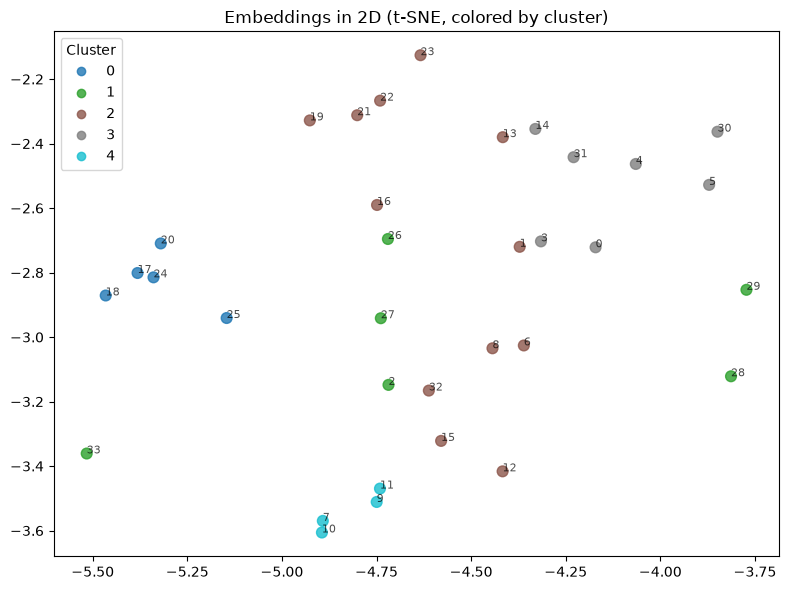

(array([[-4.171083 , -2.7216194],
        [-4.3716636, -2.7201104],
        [-4.718343 , -3.148228 ],
        [-4.3154645, -2.7032585],
        [-4.064795 , -2.4632506],
        [-3.8710399, -2.5280404],
        [-4.3607016, -3.0259607],
        [-4.8918915, -3.569951 ],
        [-4.443558 , -3.034734 ],
        [-4.7495255, -3.5112782],
        [-4.8942604, -3.6060052],
        [-4.740867 , -3.4697762],
        [-4.4167957, -3.4162998],
        [-4.4162974, -2.3801835],
        [-4.3302226, -2.3545592],
        [-4.5792937, -3.3219035],
        [-4.748623 , -2.5903997],
        [-5.3814206, -2.8012936],
        [-5.4656024, -2.871072 ],
        [-4.926248 , -2.3281686],
        [-5.3200893, -2.709657 ],
        [-4.8010025, -2.3120446],
        [-4.7404814, -2.2669165],
        [-4.6336536, -2.1259713],
        [-5.339272 , -2.81475  ],
        [-5.1460333, -2.9408846],
        [-4.7198763, -2.695857 ],
        [-4.7385955, -2.941538 ],
        [-3.8132162, -3.1215482],
        [-3.77

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans


def plot_embeddings_2d(embeddings, n_clusters=5, perplexity=30):
    X = np.array(embeddings)
    perplexity = min(perplexity, len(X) - 1)
    coords = TSNE(n_components=2, perplexity=perplexity,
                  random_state=42).fit_transform(X)

    n_clusters = min(n_clusters, len(X))
    cluster_labels = KMeans(n_clusters=n_clusters,
                            random_state=42, n_init=10).fit_predict(X)

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(coords[:, 0], coords[:, 1],
                          c=cluster_labels, cmap="tab10", s=60, alpha=0.8)
    for i, (x, y) in enumerate(coords):
        plt.annotate(str(i), (x, y), fontsize=8, alpha=0.7)

    plt.legend(*scatter.legend_elements(), title="Cluster", loc="best")
    plt.title("Embeddings in 2D (t-SNE, colored by cluster)")
    plt.tight_layout()
    plt.show()
    return coords, cluster_labels


plot_embeddings_2d(embeddings)

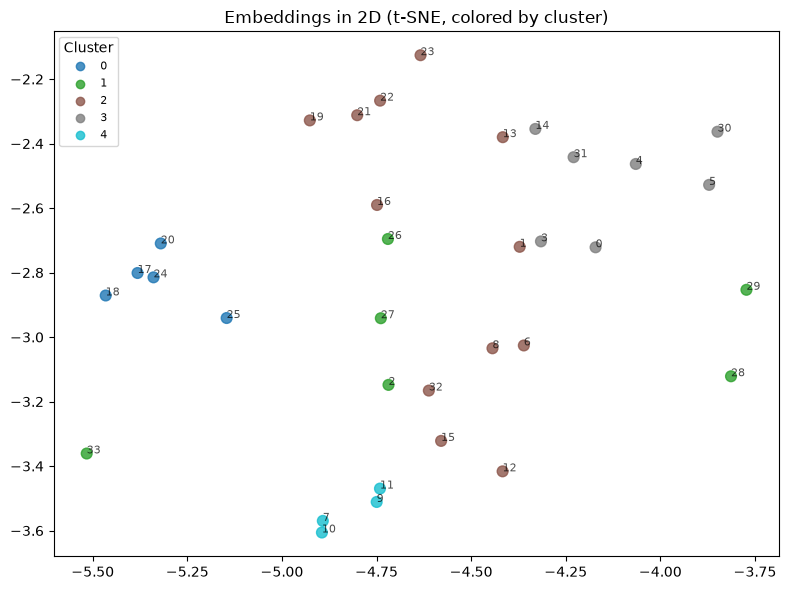

(array([[-4.171083 , -2.7216194],
        [-4.3716636, -2.7201104],
        [-4.718343 , -3.148228 ],
        [-4.3154645, -2.7032585],
        [-4.064795 , -2.4632506],
        [-3.8710399, -2.5280404],
        [-4.3607016, -3.0259607],
        [-4.8918915, -3.569951 ],
        [-4.443558 , -3.034734 ],
        [-4.7495255, -3.5112782],
        [-4.8942604, -3.6060052],
        [-4.740867 , -3.4697762],
        [-4.4167957, -3.4162998],
        [-4.4162974, -2.3801835],
        [-4.3302226, -2.3545592],
        [-4.5792937, -3.3219035],
        [-4.748623 , -2.5903997],
        [-5.3814206, -2.8012936],
        [-5.4656024, -2.871072 ],
        [-4.926248 , -2.3281686],
        [-5.3200893, -2.709657 ],
        [-4.8010025, -2.3120446],
        [-4.7404814, -2.2669165],
        [-4.6336536, -2.1259713],
        [-5.339272 , -2.81475  ],
        [-5.1460333, -2.9408846],
        [-4.7198763, -2.695857 ],
        [-4.7385955, -2.941538 ],
        [-3.8132162, -3.1215482],
        [-3.77

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans


def plot_embeddings_2d(embeddings, n_clusters=5, perplexity=30, descriptions=None):
    X = np.array(embeddings)
    perplexity = min(perplexity, len(X) - 1)
    coords = TSNE(n_components=2, perplexity=perplexity,
                  random_state=42).fit_transform(X)

    n_clusters = min(n_clusters, len(X))
    cluster_labels = KMeans(n_clusters=n_clusters,
                            random_state=42, n_init=10).fit_predict(X)

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(coords[:, 0], coords[:, 1],
                          c=cluster_labels, cmap="tab10", s=60, alpha=0.8)
    for i, (x, y) in enumerate(coords):
        plt.annotate(str(i), (x, y), fontsize=8, alpha=0.7)

    handles, default_labels = scatter.legend_elements()
    if descriptions:
        legend_labels = [descriptions.get(
            i, f"Cluster {i}") for i in range(len(handles))]
    else:
        legend_labels = default_labels
    plt.legend(handles, legend_labels, title="Cluster", loc="best", fontsize=8)

    plt.title("Embeddings in 2D (t-SNE, colored by cluster)")
    plt.tight_layout()
    plt.show()
    return coords, cluster_labels


plot_embeddings_2d(embeddings)

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans


def describe_cluster(client, chunk_texts, max_chunks=5, max_chars=300):
    sample = "\n---\n".join(c[:max_chars] for c in chunk_texts[:max_chunks])
    prompt = (
        "Here are excerpts from a group of related text chunks. "
        "In 3-6 words, give a short topic label for what they have in common.\n\n"
        f"{sample}"
    )
    response = client.chat.completions.create(
        model="gpt-4.1-mini",
        messages=[{"role": "user", "content": prompt}],
    )
    return response.choices[0].message.content.strip()


def plot_embeddings_2d(embeddings, chunks, client, n_clusters=5, perplexity=30):
    X = np.array(embeddings)
    perplexity = min(perplexity, len(X) - 1)
    coords = TSNE(n_components=2, perplexity=perplexity,
                  random_state=42).fit_transform(X)

    n_clusters = min(n_clusters, len(X))
    cluster_labels = KMeans(n_clusters=n_clusters,
                            random_state=42, n_init=10).fit_predict(X)

    descriptions = {}
    for cluster_id in range(n_clusters):
        cluster_chunks = [chunks[i] for i in range(
            len(chunks)) if cluster_labels[i] == cluster_id]
        descriptions[cluster_id] = describe_cluster(client, cluster_chunks)

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(coords[:, 0], coords[:, 1],
                          c=cluster_labels, cmap="tab10", s=60, alpha=0.8)
    for i, (x, y) in enumerate(coords):
        plt.annotate(str(i), (x, y), fontsize=8, alpha=0.7)

    handles, _ = scatter.legend_elements()
    legend_labels = [f"{i}: {descriptions[i]}" for i in range(len(handles))]
    plt.legend(handles, legend_labels, title="Cluster", loc="best", fontsize=8)

    plt.title("Embeddings in 2D (t-SNE, colored by cluster)")
    plt.tight_layout()
    plt.show()
    return coords, cluster_labels, descriptions



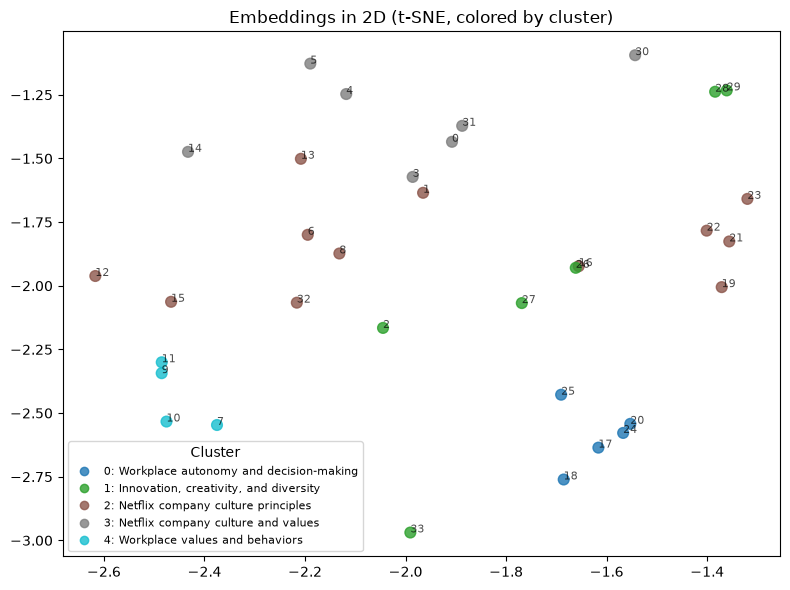

(array([[-1.907602 , -1.4345672],
        [-1.9651021, -1.6348306],
        [-2.0448241, -2.165518 ],
        [-1.9858257, -1.5725245],
        [-2.1179929, -1.2469796],
        [-2.1894226, -1.1275241],
        [-2.1945584, -1.7998384],
        [-2.3750718, -2.5468037],
        [-2.1316469, -1.8732313],
        [-2.4851096, -2.343296 ],
        [-2.475535 , -2.5332735],
        [-2.4849997, -2.3004165],
        [-2.6171067, -1.96164  ],
        [-2.2081904, -1.5013776],
        [-2.4327323, -1.4740379],
        [-2.466389 , -2.0629282],
        [-1.6555295, -1.9231532],
        [-1.6163962, -2.6357195],
        [-1.6853753, -2.7608135],
        [-1.3710661, -2.0053568],
        [-1.5528963, -2.5422626],
        [-1.3560395, -1.8259003],
        [-1.4009577, -1.7835488],
        [-1.3199571, -1.6588427],
        [-1.5671238, -2.5779634],
        [-1.6904808, -2.4278321],
        [-1.6614105, -1.9294596],
        [-1.7686951, -2.067958 ],
        [-1.3841137, -1.2379508],
        [-1.36

In [ ]:
plot_embeddings_2d(embeddings, chunks, client)

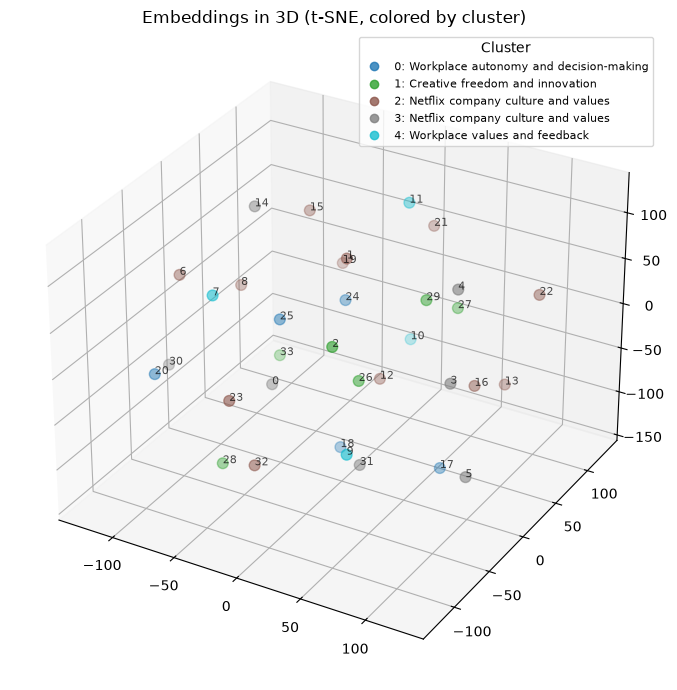

(array([[ -39.844955 ,  -27.63532  ,  -43.24394  ],
        [  12.316137 ,  -14.46715  ,  105.37422  ],
        [  39.148678 ,  -81.04914  ,   66.51236  ],
        [ 108.67233  ,  -44.45706  ,   30.144485 ],
        [  99.17736  ,  -17.577925 ,  107.75094  ],
        [ 125.51092  ,  -52.360844 ,  -58.069706 ],
        [-111.50916  ,  -31.241308 ,   51.717693 ],
        [ -46.035393 ,  -92.889824 ,   95.39713  ],
        [ -99.40445  ,   30.183937 ,    4.7712417],
        [  71.55792  , -118.519585 ,   -8.039614 ],
        [  -8.140709 ,  114.64773  ,  -78.00061  ],
        [  13.621575 ,   70.561615 ,  111.72966  ],
        [  11.716114 ,   33.506485 ,  -58.964832 ],
        [  83.66621  ,   85.514534 ,  -72.56567  ],
        [ -67.0166   ,   -2.8930275,  124.32086  ],
        [ -63.371372 ,   65.5027   ,   78.46269  ],
        [  94.37501  ,   18.286507 ,  -22.305618 ],
        [  70.057495 ,   15.441287 , -122.50379  ],
        [ -12.488301 ,   19.926619 , -137.30812  ],
        [ -6

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans


def describe_cluster(client, chunk_texts, max_chunks=5, max_chars=300):
    sample = "\n---\n".join(c[:max_chars] for c in chunk_texts[:max_chunks])
    prompt = (
        "Here are excerpts from a group of related text chunks. "
        "In 3-6 words, give a short topic label for what they have in common.\n\n"
        f"{sample}"
    )
    response = client.chat.completions.create(
        model="gpt-4.1-mini",
        messages=[{"role": "user", "content": prompt}],
    )
    return response.choices[0].message.content.strip()


def plot_embeddings_3d(embeddings, chunks, client, n_clusters=5, perplexity=30):
    X = np.array(embeddings)
    perplexity = min(perplexity, len(X) - 1)
    coords = TSNE(n_components=3, perplexity=perplexity,
                  random_state=42).fit_transform(X)

    n_clusters = min(n_clusters, len(X))
    cluster_labels = KMeans(n_clusters=n_clusters,
                            random_state=42, n_init=10).fit_predict(X)

    descriptions = {}
    for cluster_id in range(n_clusters):
        cluster_chunks = [chunks[i] for i in range(
            len(chunks)) if cluster_labels[i] == cluster_id]
        descriptions[cluster_id] = describe_cluster(client, cluster_chunks)

    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(projection="3d")
    scatter = ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2],
                         c=cluster_labels, cmap="tab10", s=60, alpha=0.8)
    for i, (x, y, z) in enumerate(coords):
        ax.text(x, y, z, str(i), fontsize=8, alpha=0.7)

    handles, _ = scatter.legend_elements()
    legend_labels = [f"{i}: {descriptions[i]}" for i in range(len(handles))]
    ax.legend(handles, legend_labels, title="Cluster", loc="best", fontsize=8)

    ax.set_title("Embeddings in 3D (t-SNE, colored by cluster)")
    plt.tight_layout()
    plt.show()
    return coords, cluster_labels, descriptions

plot_embeddings_3d(embeddings, chunks, client)

In [14]:
import numpy as np
import plotly.express as px
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans


def describe_cluster(client, chunk_texts, max_chunks=5, max_chars=300):
    sample = "\n---\n".join(c[:max_chars] for c in chunk_texts[:max_chunks])
    prompt = (
        "Here are excerpts from a group of related text chunks. "
        "In 3-6 words, give a short topic label for what they have in common.\n\n"
        f"{sample}"
    )
    response = client.chat.completions.create(
        model="gpt-4.1-mini",
        messages=[{"role": "user", "content": prompt}],
    )
    return response.choices[0].message.content.strip()


def plot_embeddings_3d(embeddings, chunks, client, n_clusters=5, perplexity=30):
    X = np.array(embeddings)
    perplexity = min(perplexity, len(X) - 1)
    coords = TSNE(n_components=3, perplexity=perplexity,
                  random_state=42).fit_transform(X)

    n_clusters = min(n_clusters, len(X))
    cluster_labels = KMeans(n_clusters=n_clusters,
                            random_state=42, n_init=10).fit_predict(X)

    descriptions = {}
    for cluster_id in range(n_clusters):
        cluster_chunks = [chunks[i] for i in range(
            len(chunks)) if cluster_labels[i] == cluster_id]
        descriptions[cluster_id] = describe_cluster(client, cluster_chunks)

    color_labels = [f"{c}: {descriptions[c]}" for c in cluster_labels]
    hover_text = [c[:150] + ("..." if len(c) > 150 else "") for c in chunks]

    fig = px.scatter_3d(
        x=coords[:, 0], y=coords[:, 1], z=coords[:, 2],
        color=color_labels,
        hover_name=hover_text,
        title="Embeddings in 3D (t-SNE, colored by cluster)",
        labels={"x": "dim 1", "y": "dim 2", "z": "dim 3", "color": "Cluster"},
    )
    fig.update_traces(marker=dict(size=6, opacity=0.8))
    fig.show()
    return coords, cluster_labels, descriptions


plot_embeddings_3d(embeddings, chunks, client)

(array([[ -39.844955 ,  -27.63532  ,  -43.24394  ],
        [  12.316137 ,  -14.46715  ,  105.37422  ],
        [  39.148678 ,  -81.04914  ,   66.51236  ],
        [ 108.67233  ,  -44.45706  ,   30.144485 ],
        [  99.17736  ,  -17.577925 ,  107.75094  ],
        [ 125.51092  ,  -52.360844 ,  -58.069706 ],
        [-111.50916  ,  -31.241308 ,   51.717693 ],
        [ -46.035393 ,  -92.889824 ,   95.39713  ],
        [ -99.40445  ,   30.183937 ,    4.7712417],
        [  71.55792  , -118.519585 ,   -8.039614 ],
        [  -8.140709 ,  114.64773  ,  -78.00061  ],
        [  13.621575 ,   70.561615 ,  111.72966  ],
        [  11.716114 ,   33.506485 ,  -58.964832 ],
        [  83.66621  ,   85.514534 ,  -72.56567  ],
        [ -67.0166   ,   -2.8930275,  124.32086  ],
        [ -63.371372 ,   65.5027   ,   78.46269  ],
        [  94.37501  ,   18.286507 ,  -22.305618 ],
        [  70.057495 ,   15.441287 , -122.50379  ],
        [ -12.488301 ,   19.926619 , -137.30812  ],
        [ -6